In [1]:
!pip install ultralytics --quiet

import os
for root, dirs, files in os.walk("/kaggle/input"):
    print(root, len(files))
    if files:
        print("  sample:", files[:3])

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.1 MB/s eta 0:00:00
/kaggle/input 0
/kaggle/input/datasets 0
/kaggle/input/datasets/adilshamim8 0
/kaggle/input/datasets/adilshamim8/license-plate-recognition 0
/kaggle/input/datasets/adilshamim8/license-plate-recognition/valid 0
/kaggle/input/datasets/adilshamim8/license-plate-recognition/valid/valid 2049
  sample: ['CarLongPlateGen2256_jpg.rf.fdb57b471473e661eb9bbecdcde15eae.jpg', 'CarLongPlateGen2681_jpg.rf.1f1260b6edfad46676589a2f4db5bbb4.jpg', 'CarLongPlateGen1345_jpg.rf.6e7403365478ed53fbd0bd81d5f6c3ae.jpg']
/kaggle/input/datasets/adilshamim8/license-plate-recognition/test 0
/kaggle/input/datasets/adilshamim8/license-plate-recognition/test/test 1021
  sample: ['xemay2226_jpg.rf.46aee8ad3062ed22338fff531118ac5e.jpg', 'xemay1836_jpg.rf.63b25170085c253acd0f89ee85382ae7.jpg', 'xemay1040_jpg.rf.ad77238fd1b902b4ab9189f4958c4f4a.jpg']
/kaggle/input/dat

In [ ]:
import os

train_dir = "/kaggle/input/datasets/adilshamim8/license-plate-recognition/train/train"
files = os.listdir(train_dir)


extensions = {}
for f in files:
    ext = f.split('.')[-1]
    extensions[ext] = extensions.get(ext, 0) + 1

print(extensions)

{'jpg': 7057, 'csv': 1}


In [ ]:
import pandas as pd

csv_path = "/kaggle/input/datasets/adilshamim8/license-plate-recognition/train/train/_annotations.csv"

import os
for f in os.listdir("/kaggle/input/datasets/adilshamim8/license-plate-recognition/train/train"):
    if f.endswith('.csv'):
        print("اسم الملف الفعلي:", f)
        csv_path = os.path.join("/kaggle/input/datasets/adilshamim8/license-plate-recognition/train/train", f)

df = pd.read_csv(csv_path)
print(df.shape)
print(df.columns.tolist())
print(df.head(5))

اسم الملف الفعلي: _annotations.csv
(7357, 8)
['filename', 'width', 'height', 'class', 'xmin', 'ymin', 'xmax', 'ymax']
                                            filename  width  height  \
0  xemay1793_jpg.rf.0dc26bab2eb4bb60c25bf0430a744...    472     303   
1  xemay1850_jpg.rf.a89277812aac9136da653af67d7e3...    472     303   
2  rotatequandoi50_jpg.rf.fcc6a91af1b79436df370a0...    764     428   
3  Cars354_png_jpg.rf.52d6d5fb18efb7075b02ccc55c4...    400     267   
4  CarLongPlateGen2076_jpg.rf.2c1888f949cec4ec6e8...    472     303   

           class  xmin  ymin  xmax  ymax  
0  License_Plate   154    82   218   127  
1  License_Plate   187   122   249   169  
2  License_Plate   260   322   325   370  
3  License_Plate    64   201   101   221  
4  License_Plate   316   242   412   271  


In [ ]:
import pandas as pd
import os
from tqdm import tqdm


splits = {
    "train": "/kaggle/input/datasets/adilshamim8/license-plate-recognition/train/train",
    "valid": "/kaggle/input/datasets/adilshamim8/license-plate-recognition/valid/valid",
    "test": "/kaggle/input/datasets/adilshamim8/license-plate-recognition/test/test",
}

output_base = "/kaggle/working/plate_dataset_yolo"

for split_name, split_path in splits.items():
    
    img_out = os.path.join(output_base, split_name, "images")
    lbl_out = os.path.join(output_base, split_name, "labels")
    os.makedirs(img_out, exist_ok=True)
    os.makedirs(lbl_out, exist_ok=True)

    
    csv_path = os.path.join(split_path, "_annotations.csv")
    df = pd.read_csv(csv_path)

    for filename in tqdm(df['filename'].unique(), desc=f"{split_name} images"):
        src = os.path.join(split_path, filename)
        dst = os.path.join(img_out, filename)
        if os.path.exists(src) and not os.path.exists(dst):
            os.symlink(src, dst)

    
    grouped = df.groupby('filename')
    for filename, group in tqdm(grouped, desc=f"{split_name} labels"):
        label_filename = os.path.splitext(filename)[0] + ".txt"
        label_path = os.path.join(lbl_out, label_filename)

        lines = []
        for _, row in group.iterrows():
            img_w, img_h = row['width'], row['height']
            xmin, ymin, xmax, ymax = row['xmin'], row['ymin'], row['xmax'], row['ymax']

            
            x_center = ((xmin + xmax) / 2) / img_w
            y_center = ((ymin + ymax) / 2) / img_h
            w = (xmax - xmin) / img_w
            h = (ymax - ymin) / img_h

            
            lines.append(f"0 {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}")

        with open(label_path, 'w') as f:
            f.write("\n".join(lines))

print("✅ خلص التحويل")

test labels: 100%|██████████| 1019/1019 [00:00<00:00, 4037.36it/s]

✅ خلص التحويل


In [ ]:

for split in ["train", "valid", "test"]:
    n_img = len(os.listdir(f"{output_base}/{split}/images"))
    n_lbl = len(os.listdir(f"{output_base}/{split}/labels"))
    print(f"{split}: {n_img} images, {n_lbl} labels")

train: 7052 images, 7052 labels
valid: 2045 images, 2045 labels
test: 1019 images, 1019 labels


In [6]:
yaml_content = f"""
train: {output_base}/train/images
val: {output_base}/valid/images
test: {output_base}/test/images

nc: 1
names: ['plate']
"""

with open("/kaggle/working/data.yaml", "w") as f:
    f.write(yaml_content)

print(yaml_content)


train: /kaggle/working/plate_dataset_yolo/train/images
val: /kaggle/working/plate_dataset_yolo/valid/images
test: /kaggle/working/plate_dataset_yolo/test/images

nc: 1
names: ['plate']



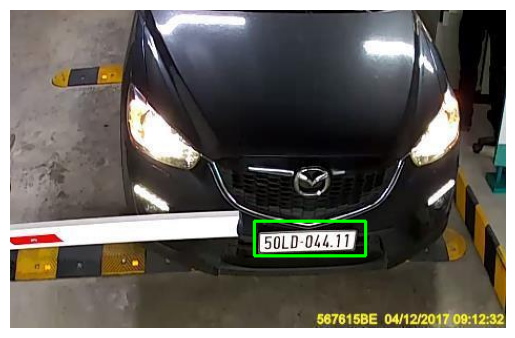

In [7]:
import cv2
import matplotlib.pyplot as plt

img_name = os.listdir(f"{output_base}/train/images")[0]
img_path = f"{output_base}/train/images/{img_name}"
lbl_path = f"{output_base}/train/labels/{os.path.splitext(img_name)[0]}.txt"

img = cv2.imread(img_path)
h, w = img.shape[:2]

with open(lbl_path) as f:
    for line in f:
        cls, xc, yc, bw, bh = map(float, line.split())
        x1 = int((xc - bw/2) * w)
        y1 = int((yc - bh/2) * h)
        x2 = int((xc + bw/2) * w)
        y2 = int((yc + bh/2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [8]:
from ultralytics import YOLO

model = YOLO("yolo26s.pt")

results = model.train(
    data="/kaggle/working/data.yaml",
    epochs=100,
    imgsz=640,
    device=[-1,-1],
    batch=16,
    patience=20,
    project="/kaggle/working/InfernoGuard",
    name="plate_detector_v1"
)

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Searching for 2 idle GPUs with free memory >= 20.0% and free utilization >= 0.0%...
Selected idle CUDA devices [0, 1]
Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                        CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0,1